# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 RealWaste Images Dataset

In [123]:
# Import necessary libraries
# - data handling
import pandas as pd
import numpy as np

from warnings import filterwarnings
filterwarnings('ignore')

# - plotting
import matplotlib.pyplot as plt
import seaborn as sns

# - text preprocessing
import nltk
import re
import string
from collections import Counter
from sklearn.preprocessing import LabelEncoder

# - NLP libraries
from nltk.tokenize import word_tokenize,sent_tokenize, RegexpTokenizer
from sentence_transformers import SentenceTransformer
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer,WordNetLemmatizer, SnowballStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.util import ngrams

# -  NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

# - sklearn libraries
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# - deep learning libraries
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, DistilBertTokenizerFast, AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense,Conv2D, Flatten, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2


# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


DATASET STRUCTURE
Number of categories: 9
Categories:
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation

DISTRIBUTION OF WASTE CATEGORIES
           Category  Number_of_Images
            Plastic               921
              Metal               790
              Paper               500
Miscellaneous Trash               495
          Cardboard               461
         Vegetation               436
              Glass               420
      Food Organics               411
      Textile Trash               318

Total number of images: 4752


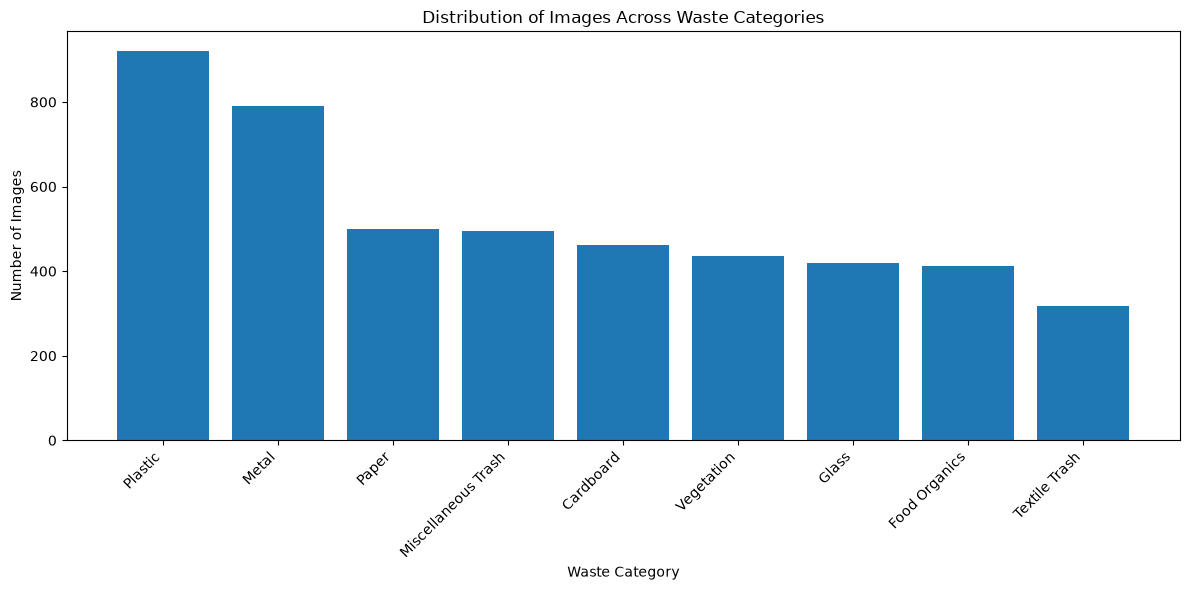


IMAGE CHARACTERISTICS

Image formats:
Format
JPEG    4752
Name: count, dtype: int64

Color modes:
Mode
RGB    4752
Name: count, dtype: int64

IMAGE RESOLUTION

Width statistics:
count    4752.0
mean      524.0
std         0.0
min       524.0
25%       524.0
50%       524.0
75%       524.0
max       524.0
Name: Width, dtype: float64

Height statistics:
count    4752.0
mean      524.0
std         0.0
min       524.0
25%       524.0
50%       524.0
75%       524.0
max       524.0
Name: Height, dtype: float64

Most common resolutions:
Width  Height
524    524       4752
dtype: int64

Number of very small images: 0

SAMPLE IMAGES - QUALITY AND BACKGROUND INSPECTION


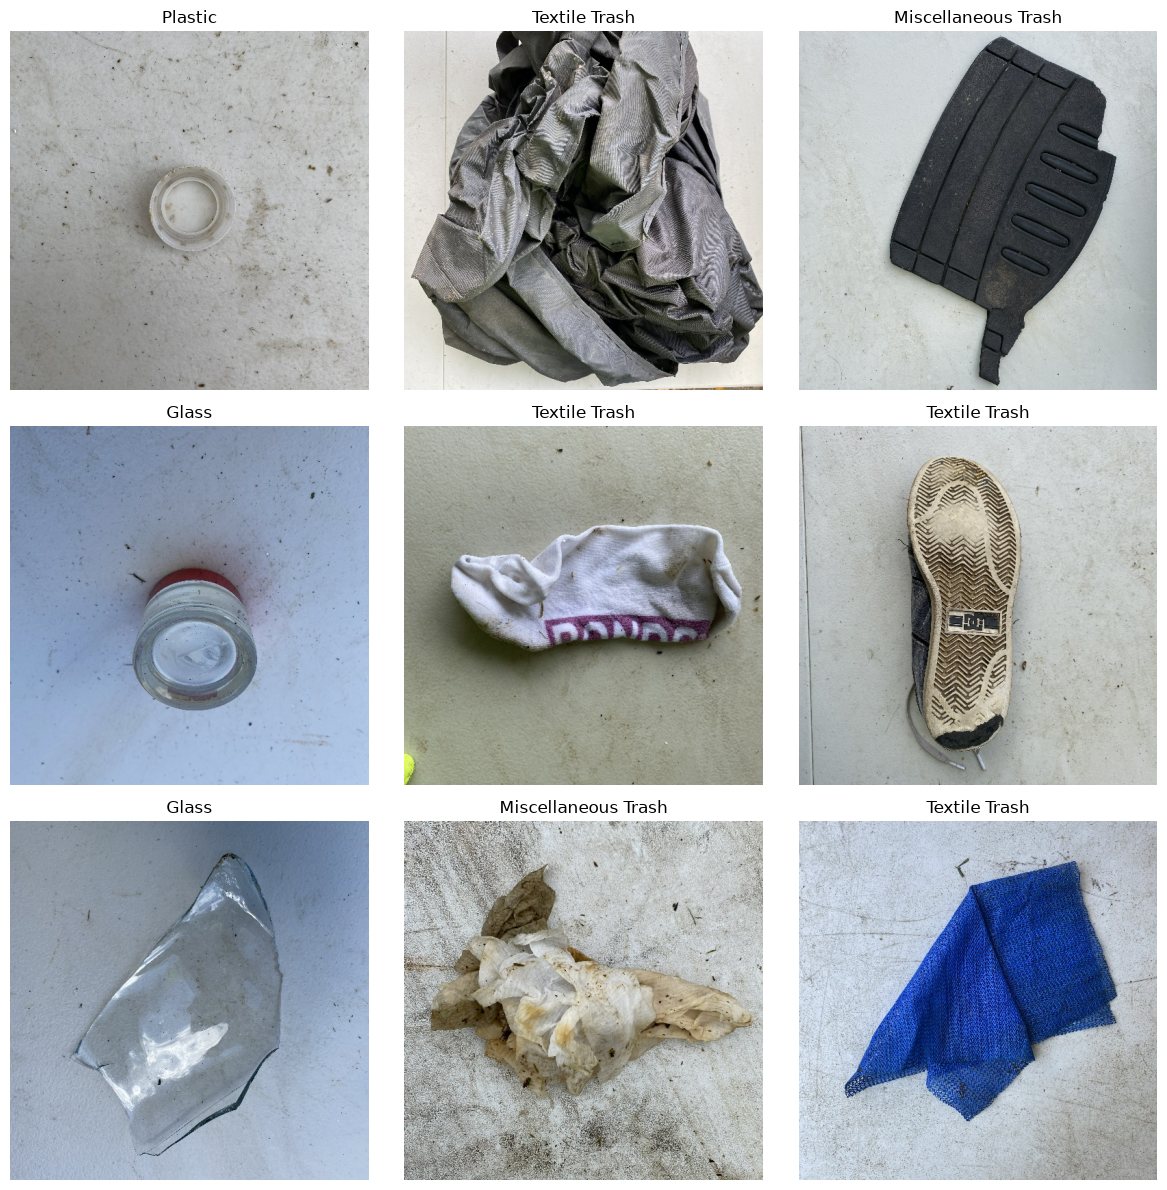

In [2]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here
import os
from PIL import Image

#loading of the datasets

# Loading the RealWaste dataset on google colab
# from google.colab import drive
# drive.mount('/content/drive')

# os.listdir('/content/drive/MyDrive')

# 1. Dataset path
realwaste_path = "RealWaste/"

# 2. Find waste categories
categories = [
    folder for folder in os.listdir(realwaste_path)
    if os.path.isdir(os.path.join(realwaste_path, folder))
]

print("=" * 50)
print("DATASET STRUCTURE")
print("=" * 50)

print("Number of categories:", len(categories))
print("Categories:")

for category in sorted(categories):
    print("-", category)


# 3. Count images in each category
category_counts = {}

for category in categories:
    category_path = os.path.join(realwaste_path, category)

    images = [
        file for file in os.listdir(category_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ]

    category_counts[category] = len(images)

category_df = pd.DataFrame(
    list(category_counts.items()),
    columns=['Category', 'Number_of_Images']
)

category_df = category_df.sort_values(
    'Number_of_Images',
    ascending=False
)

print("\n" + "=" * 50)
print("DISTRIBUTION OF WASTE CATEGORIES")
print("=" * 50)

print(category_df.to_string(index=False))

print("\nTotal number of images:", category_df['Number_of_Images'].sum())


# 4. Plot category distribution
plt.figure(figsize=(12, 6))

plt.bar(
    category_df['Category'],
    category_df['Number_of_Images']
)

plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Images Across Waste Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 5. Collect image characteristics
image_info = []

for category in categories:

    category_path = os.path.join(realwaste_path, category)

    for file in os.listdir(category_path):

        if file.lower().endswith(
            ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        ):

            file_path = os.path.join(category_path, file)

            try:
                with Image.open(file_path) as img:

                    image_info.append({
                        'Category': category,
                        'Filename': file,
                        'Width': img.width,
                        'Height': img.height,
                        'Format': img.format,
                        'Mode': img.mode
                    })

            except Exception as e:
                print("Could not read:", file_path)


image_df = pd.DataFrame(image_info)


# 6. Image characteristics
print("\n" + "=" * 50)
print("IMAGE CHARACTERISTICS")
print("=" * 50)

print("\nImage formats:")
print(image_df['Format'].value_counts())

print("\nColor modes:")
print(image_df['Mode'].value_counts())


# 7. Resolution
print("\n" + "=" * 50)
print("IMAGE RESOLUTION")
print("=" * 50)

print("\nWidth statistics:")
print(image_df['Width'].describe())

print("\nHeight statistics:")
print(image_df['Height'].describe())

print("\nMost common resolutions:")

resolution_counts = (
    image_df
    .groupby(['Width', 'Height'])
    .size()
    .sort_values(ascending=False)
)

print(resolution_counts.head(10))


# 8. Check for very small images
small_images = image_df[
    (image_df['Width'] < 100) |
    (image_df['Height'] < 100)
]

print("\nNumber of very small images:", len(small_images))


# 9. Display sample images
print("\n" + "=" * 50)
print("SAMPLE IMAGES - QUALITY AND BACKGROUND INSPECTION")
print("=" * 50)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax in axes.flat:

    category = np.random.choice(categories)

    category_path = os.path.join(realwaste_path, category)

    files = [
        file for file in os.listdir(category_path)
        if file.lower().endswith(
            ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        )
    ]

    file = np.random.choice(files)
    file_path = os.path.join(category_path, file)

    img = Image.open(file_path)

    ax.imshow(img)
    ax.set_title(category)
    ax.axis('off')

plt.tight_layout()
plt.show()

### RealWaste Dataset

The **RealWaste image dataset** contains **4,752 waste images distributed across these nine categories**: Plastic, Metal, Paper, Miscellaneous Trash, Cardboard, Vegetation, Glass, Food Organics, and Textile Trash. 

#### Distribution of Waste Categories

The dataset seems to be a little bit **imbalanced**. **Plastic** is the most represented category with 921 images, followed by **Metal** with 790 images. In comparison, **Paper** 500, **Miscellaneous Trash** 495, **Cardboard** 461, **Vegetation** 436, **Glass** 420, **Food Organics** 411,  **Textile Trash** is the least represented category with 318 images.                        

#### Image Format

All images are completely consistent file format in JPEG, Therefore there is no need to account for multiple image formats or develop separate processing procedures for different file types.

#### Colour Characteristics

The images contain the standard **three colour channels: Red, Green, and Blue**. There are no grayscale or alternative colour-mode images in the dataset. Therefore, the model can be configured to expect an input shape containing three channels without requiring conversion of grayscale or differently encoded images. RGB colour mode will also provide useful visual features when distinguishing waste materials. 

#### Image Resolution

Aa the images have a resolution of **524 × 524 pixels**. Both width and height have:

- Mean = **524 pixels**
- Minimum = **524 pixels**
- Maximum = **524 pixels**
- Standard deviation = **0 pixels**

The zero standard deviation confirms that there is no variation in image dimensions. The images will be resized to a standard input size that match the requirements of the CNN architecture and reduce computational cost during training.

### Small Image and Quality Check

There are no unusually low-resolution images. 

### Implications for CNN Development

Overall, the RealWaste dataset is technically consistent and suitable for developing the image-classification component of the EcoSort system. The main issue identified during initial exploration is the **unequal number of images across the nine waste categories**.

### 1.2 Text Datasets

#### 1.2.1 Waste_descriptions dataset

In [3]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
df_description = pd.read_csv('waste_descriptions.csv')
df_description.head()

,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


##### Vocabulary and Structure of Waste Description Dataset


In [4]:
#Checking shape of the dataset
print(df_description.shape)

#Checking the column names
print(df_description.columns)

#Knowing the overall info about the dataset
print(df_description.info())

#Checking for missing values
print(df_description.isnull().sum())

(5000, 5)
Index(['description', 'category', 'disposal_instruction', 'common_confusion',
       'material_composition'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   description           5000 non-null   str  
 1   category              5000 non-null   str  
 2   disposal_instruction  5000 non-null   str  
 3   common_confusion      2496 non-null   str  
 4   material_composition  5000 non-null   str  
dtypes: str(5)
memory usage: 1.1 MB
None
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


##### Distribution of categories for Waste Description Dataset

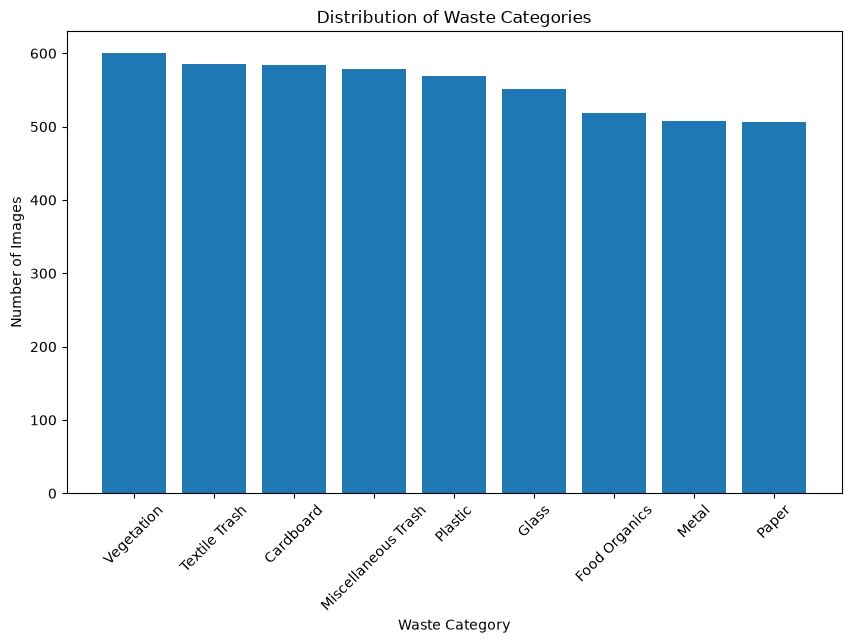

In [5]:
# understand the distribution of  categories
category_counts = df_description['category'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(category_counts.index,category_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Waste Categories')
plt.show()

#### 1.2.2 WASTE POLICY DOCUMENTS DATASET

In [124]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Your code here
df_policy_documents =  pd.read_json('waste_policy_documents.json')
display(df_policy_documents.head())

#Checking the shape of the dataset
print(df_policy_documents.shape)

#Understanding document organization an language

print(df_policy_documents.info())

#checking the column names
print(df_policy_documents.columns)

#Checking the datatypes for each column
print(df_policy_documents.dtypes)

,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City


(14, 6)
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     str   
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     str   
 4   document_text       14 non-null     str   
 5   jurisdiction        14 non-null     str   
dtypes: int64(1), object(1), str(4)
memory usage: 10.8+ KB
None
Index(['policy_id', 'policy_type', 'categories_covered', 'effective_date',
       'document_text', 'jurisdiction'],
      dtype='str')
policy_id              int64
policy_type              str
categories_covered    object
effective_date           str
document_text            str
jurisdiction             str
dtype: object


### 1.3 Create Data Pipelines

#### 1.3.1 Image Processing Pipeline

In [7]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)


validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


#### 1.3.2 Text Preprocessing Pipeline

In [34]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# - Text cleaning
def clean_text(text):
    """
    Clean text by:
    - converting to lowercase
    - removing URLs
    - removing special characters
    - removing extra whitespace
    """
    
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Keep letters, numbers, spaces and hyphens
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


# Apply cleaning
df_description["clean_description"] = (
    df_description["description"]
    .fillna("")
    .apply(clean_text)
)


# Encode target labels

label_encoder = LabelEncoder()

df_description["label"] = label_encoder.fit_transform(
    df_description["category"]
)

X_all_text = df_description["clean_description"].to_numpy(dtype=str)
y_all_text = df_description["label"].to_numpy(dtype=np.int64)


# Split data into train and test sets

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_all_text,
    y_all_text,
    test_size=0.20,
    random_state=42,
    stratify=y_all_text
)

# Tokenization / Text Vectorization

VOCAB_SIZE = 10000
MAX_LEN = 40

text_vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    standardize=None,          # Already cleaned above
    split="whitespace",        # Tokenization
    output_mode="int",
    output_sequence_length=MAX_LEN
)

# Learn vocabulary ONLY from training data
text_vectorizer.adapt(
    tf.data.Dataset
    .from_tensor_slices(X_train_text)
    .batch(256)
)


# Convert text into integer token sequences
X_train_tokens = text_vectorizer(X_train_text)
X_test_tokens = text_vectorizer(X_test_text)


# Create Embeddings / Features

vocab_size = len(text_vectorizer.get_vocabulary())

EMBEDDING_DIM = 128

embedding_layer = layers.Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="text_embedding"
)

# Convert token sequences into dense vector representations
X_train_embeddings = embedding_layer(X_train_tokens)
X_test_embeddings = embedding_layer(X_test_tokens)


# Check Results

print("Train samples:", len(X_train_text))
print("Test samples:", len(X_test_text))

print("\nClasses:")
print(list(label_encoder.classes_))

print("\nVocabulary size:", vocab_size)

print("\nExample cleaned text:")
print(X_train_text[0])

print("\nExample tokenized text:")
print(X_train_tokens[0].numpy())

print("\nToken shape:", X_train_tokens.shape)
print("Embedding shape:", X_train_embeddings.shape)

Train samples: 4000
Test samples: 1000

Classes:
['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']

Vocabulary size: 307

Example cleaned text:
enormous pink flyer

Example tokenized text:
[ 24  59 266   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Token shape: (4000, 40)
Embedding shape: (4000, 40, 128)


#### 1.3.3 Document processing pipeline 

In [125]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here

# Make a copy of the policy documents
rag_documents = df_policy_documents.copy()

# Convert each row into one text document
rag_documents["document_text"] = rag_documents.astype(str).agg(" ".join, axis=1)

# Remove duplicate documents based only on the text
rag_documents = rag_documents.drop_duplicates(
    subset=["document_text"]
).reset_index(drop=True)

# Create the embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings for the documents
document_embeddings = embedding_model.encode(
    rag_documents["document_text"].tolist(),
    convert_to_numpy=True
)

# Check the results
print("Number of documents:", len(rag_documents))
print("Embedding shape:", document_embeddings.shape)

# Display the prepared documents
rag_documents[["document_text"]].head()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Number of documents: 14
Embedding shape: (14, 384)


,document_text
0,1 Textile Trash Recycling Guidelines ['Textile...
1,2 Glass Recycling Guidelines ['Glass'] 2023-01...
2,3 Food Organics Recycling Guidelines ['Food Or...
3,4 Plastic Recycling Guidelines ['Plastic'] 202...
4,5 Vegetation Recycling Guidelines ['Vegetation...


In [127]:
# RAG document preprocessing
rag_data = df_description.copy()

# Replace missing confusion information
rag_data["common_confusion"] = rag_data["common_confusion"].fillna(
    "No specific common confusion provided."
)

# Create a document containing useful waste-management information
rag_data["rag_document"] = (
    "Waste category: " + rag_data["category"] +
    ". Material composition: " + rag_data["material_composition"] +
    ". Disposal instruction: " + rag_data["disposal_instruction"] +
    ". Common confusion: " + rag_data["common_confusion"]
)

# Display examples
rag_data[
    ["category", "rag_document"]
].head()

,category,rag_document
0,Textile Trash,Waste category: Textile Trash. Material compos...
1,Glass,Waste category: Glass. Material composition: S...
2,Food Organics,Waste category: Food Organics. Material compos...
3,Textile Trash,Waste category: Textile Trash. Material compos...
4,Food Organics,Waste category: Food Organics. Material compos...


In [128]:
# Remove exact duplicate documents
rag_documents = rag_data["rag_document"].drop_duplicates().reset_index(drop=True)

print("Number of unique RAG documents:", len(rag_documents))

Number of unique RAG documents: 90


In [129]:
# Create embeddings for RAGto allow the system to later compare a resident's question or waste category with the stored waste-management information.

from sentence_transformers import SentenceTransformer
# Load a sentence-transformer model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings for the RAG documents
rag_embeddings = embedding_model.encode(
    rag_documents.tolist(),
    show_progress_bar=True
)

print("Number of documents:", len(rag_documents))
print("Embedding shape:", rag_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Number of documents: 90
Embedding shape: (90, 384)


In [131]:
# level RAG knowledge base to give compact RAG knowledge base containing one document for each waste category.
category_documents = []

for category, group in df_description.groupby("category"):

    # Get unique instructions
    instructions = group["disposal_instruction"].dropna().unique()

    # Get material composition
    composition = group["material_composition"].dropna().unique()

    # Get common confusion information
    confusions = group["common_confusion"].dropna().unique()

    document = (
        f"Waste Category: {category}\n"
        f"Material Composition: {composition[0]}\n"
        f"Disposal Instructions: {' '.join(instructions)}\n"
        f"Common Confusion: {' '.join(confusions)}"
    )

    category_documents.append({
        "category": category,
        "document": document
    })

rag_category_df = pd.DataFrame(category_documents)

rag_category_df.head()

,category,document
0,Cardboard,Waste Category: Cardboard\nMaterial Compositio...
1,Food Organics,Waste Category: Food Organics\nMaterial Compos...
2,Glass,Waste Category: Glass\nMaterial Composition: S...
3,Metal,Waste Category: Metal\nMaterial Composition: A...
4,Miscellaneous Trash,Waste Category: Miscellaneous Trash\nMaterial ...


In [132]:
# Create embeddings for the category-level knowledge base

rag_category_embeddings = embedding_model.encode(
    rag_category_df["document"].tolist(),
    show_progress_bar=True
)

print("Embedding shape:", rag_category_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding shape: (9, 384)


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [44]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here
# 2.1 Preprocess Images

# Data augmentation for training images
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# Apply augmentation only to the training dataset
train_ds = train_ds.map(
    lambda images, labels: (data_augmentation(images, training=True), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Keep validation and test images unchanged
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Image preprocessing completed.")

Image preprocessing completed.


### 2.2 Implement CNN Model with Transfer Learning

In [45]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here
# Number of waste categories
num_classes = 9

# Load MobileNetV2 without its original classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the pretrained layers
base_model.trainable = False

# Build the CNN model
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    # Regularization
    layers.Dropout(0.3),

    # Custom classification layer for 9 waste categories
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    layers.Dropout(0.3),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])

# Configure the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2.3 Train and Evaluate the Model

In [46]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks to reduce overfitting and improve training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 70s 542ms/step - accuracy: 0.3651 - loss: 1.9748 - val_accuracy: 0.2298 - val_loss: 2.3859 - learning_rate: 0.0010
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 66s 550ms/step - accuracy: 0.4648 - loss: 1.6576 - val_accuracy: 0.2681 - val_loss: 2.3685 - learning_rate: 0.0010
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 65s 523ms/step - accuracy: 0.5018 - loss: 1.5389 - val_accuracy: 0.2638 - val_loss: 2.4068 - learning_rate: 0.0010
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 77s 495ms/step - accuracy: 0.5121 - loss: 1.4898 - val_accuracy: 0.3277 - val_loss: 2.0675 - learning_rate: 0.0010
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 60s 496ms/step - accuracy: 0.5281 - loss: 1.4322 - val_accuracy: 0.2894 - val_loss: 2.3063 - learning_rate: 0.0010
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 59s 485ms/step - accuracy: 0.5439 - loss: 1.3942 - val_accuracy: 0.2787 - val_loss: 2.2579 - learning_rate: 0.0010
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 54s 444ms/step - accuracy: 0.5

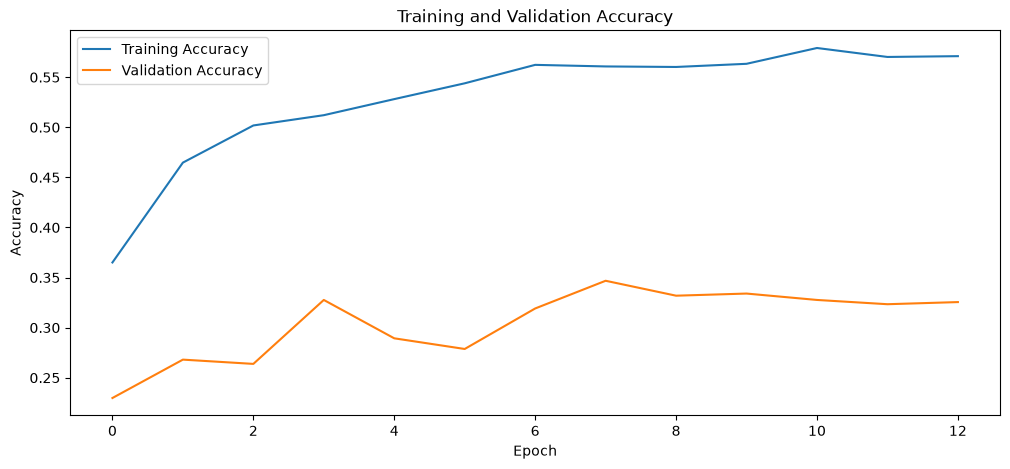

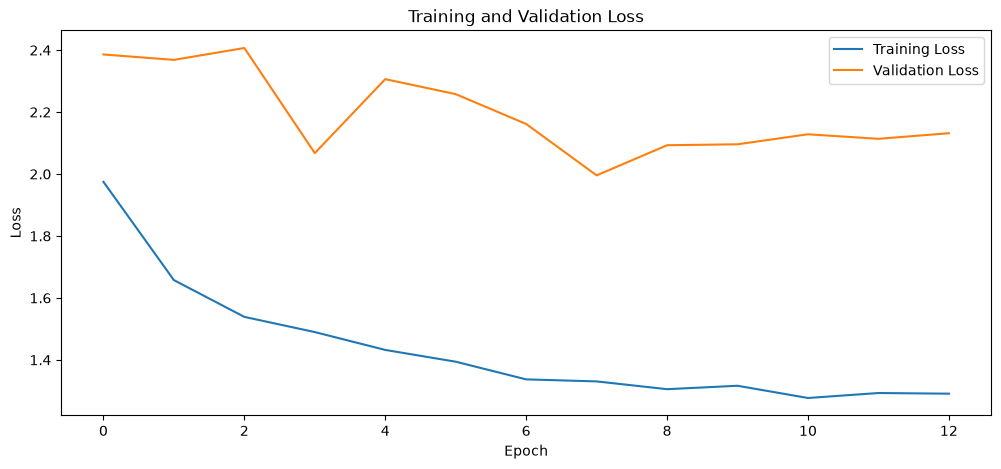

In [47]:
# Plot accuracy and loss

plt.figure(figsize=(12, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 416ms/step - accuracy: 0.3167 - loss: 2.0816
Test Loss: 2.0816397666931152
Test Accuracy: 0.3166666626930237

Calculated Test Accuracy: 0.31666666666666665

Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.43      0.41      0.42        37
      Food Organics       0.25      0.36      0.30        36
              Glass       0.67      0.05      0.10        37
              Metal       0.60      0.34      0.44        93
Miscellaneous Trash       0.00      0.00      0.00        52
              Paper       0.94      0.23      0.37        66
            Plastic       0.33      0.48      0.39        81
      Textile Trash       1.00      0.05      0.09        43
         Vegetation       0.18      0.97      0.30        35

           accuracy                           0.32       480
          macro avg       0.49      0.32      0.27       480
       weighted avg       0.51      0.32      0.29      

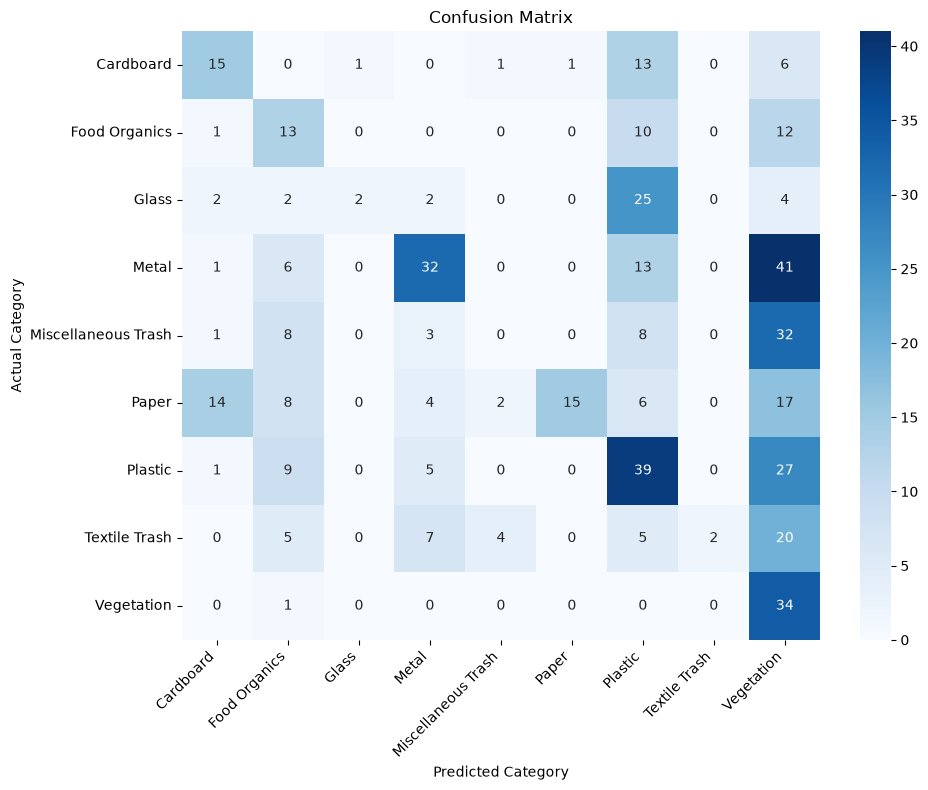

In [48]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# Generate predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(),axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print("\nCalculated Test Accuracy:", accuracy)


# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Fine-tune the Model

In [49]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here
# Unfreeze the base model
base_model.trainable = True

# Freeze the earlier layers and fine-tune only the later layers
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


# Rebuild classification head with Dropout
x = base_model.output

# Convert feature maps into a vector
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Add dropout to reduce overfitting
x = tf.keras.layers.Dropout(0.4)(x)

# Final classification layer
outputs = tf.keras.layers.Dense(
    num_classes,
    activation='softmax'
)(x)

# Create fine-tuned model
model = tf.keras.Model(
    inputs=base_model.input,
    outputs=outputs
)

# Recompile with a much smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-6
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning callbacks
early_stopping_fine = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr_fine = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Fine-tune the model
fine_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[
        early_stopping_fine,
        reduce_lr_fine
    ]
)

# Final evaluation
fine_test_loss, fine_test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("Fine-tuned Test Loss:", fine_test_loss)
print("Fine-tuned Test Accuracy:", fine_test_accuracy)

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 422ms/step - accuracy: 0.1597 - loss: 2.4328 - val_accuracy: 0.2638 - val_loss: 2.1236 - learning_rate: 5.0000e-06
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 50s 409ms/step - accuracy: 0.2470 - loss: 2.0511 - val_accuracy: 0.2702 - val_loss: 2.0299 - learning_rate: 5.0000e-06
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 55s 453ms/step - accuracy: 0.3403 - loss: 1.8750 - val_accuracy: 0.2723 - val_loss: 1.9884 - learning_rate: 5.0000e-06
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 83s 457ms/step - accuracy: 0.3769 - loss: 1.7740 - val_accuracy: 0.2851 - val_loss: 1.9617 - learning_rate: 5.0000e-06
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 57s 472ms/step - accuracy: 0.4045 - loss: 1.7003 - val_accuracy: 0.2979 - val_loss: 1.9547 - learning_rate: 5.0000e-06
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 58s 473ms/step - accuracy: 0.4232 - loss: 1.6405 - val_accuracy: 0.3000 - val_loss: 1.9534 - learning_rate: 5.0000e-06
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 56s 46

### CNN Model Training and Evaluation Summary

The CNN achieved a **test accuracy of 36.46%** with a **test loss of 1.784**. The model learned some patterns but could not properly distinguish between the waste categories.

The model correctly identified most vegetation images at a recall (94%), but with a precision of 32%. This means that other waste categories were frequently misclassified as vegetation. 

Paper and Textile Trash had precision of 76% and 78% and recall of 33% and 16% respectively. The model missed many actual examples from these categories. 

Metal phad a precision of 60% and an F1-score of 46%. 
Glass had 5% recall and a 9% F1-score. This means that the model had a significant difficulty recognizing glass images.

The overall**macro F1-score was 0.33 and weighted F1-score was 0.35**, to mean that the model performed relatively low and uneven across the waste categories. 

However, the differences between precision and recall across classes could be affected by the **class imbalance in the RealWaste dataset** and by similarities in the visual appearance of different waste materials.

The CNN model therefore required tuning for it to be reliable. 

### CNN Model Tuning


Based on training history, the strongest point appears around epoch 12-13, whereby training accuracy is about 57.8%, validation accuracy 39.8%, and validation loss falls to about 1.746. Epoch 13 gives the highest validation accuracy shown, 40.2%, but validation loss begins increasing slightly. After that, training accuracy continues toward 61%, while validation accuracy falls to about 38%. That change at epoch13 shows that the model is beginning to overfit. 

As such, EarlyStopping is important for tuning the model to be a ble to use the appropriate epoch. Other tuning parameters to improve performance included reducing learning rate, adding regularization, dropout, and modifying architecture.

### Fine-Tuning Evaluation

Fine-tuning did **not improve the CNN's performance** on the test dataset. Before fine-tuning, the model achieved a **test accuracy of 36.67%** with a **test loss of 1.7845**. After fine-tuning, test accuracy decreased to **34.17%**, while test loss increased to **1.8116**, a decrease of approximately **2.5 percentage points in test accuracy**. 

The fine-tuned model's predictions became slightly less accurate hence the original model seem to generalize better to unseen images than the fine-tuned version.

For further model improvement, other strategies or experimenting with a different transfer-learning architecture rather.


## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data


In [51]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Apply tokenization/vectorization to the training and test text
X_train_processed = text_vectorizer(X_train_text)
X_test_processed = text_vectorizer(X_test_text)

# Apply the embedding layer to create text features
X_train_embeddings = embedding_layer(X_train_processed)
X_test_embeddings = embedding_layer(X_test_processed)

# Check the processed data
print("Training token shape:", X_train_processed.shape)
print("Testing token shape:", X_test_processed.shape)

print("Training embedding shape:", X_train_embeddings.shape)
print("Testing embedding shape:", X_test_embeddings.shape)

# Display one example
print("\nOriginal text:")
print(X_train_text[0])

print("\nTokenized text:")
print(X_train_processed[0].numpy())

print("\nEmbedding shape for one sample:")
print(X_train_embeddings[0].shape)

Training token shape: (4000, 40)
Testing token shape: (1000, 40)
Training embedding shape: (4000, 40, 128)
Testing embedding shape: (1000, 40, 128)

Original text:
enormous pink flyer

Tokenized text:
[ 24  59 266   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Embedding shape for one sample:
(40, 128)


### 3.2 Implement Text Classification Model

This section implements a transformer-based text-classification model using **DistilBERT**.

`distilbert-base-uncased` is loaded as a pretrained language model and adapted to predict the waste categories in the dataset. The model receives the tokenised waste descriptions and produces a probability for each possible category.

All pretrained DistilBERT layers are left trainable. This allows the model to fine-tune its existing language knowledge to the waste-classification task.

The implementation includes:

- Loading the pretrained DistilBERT tokenizer.
- Creating a custom PyTorch dataset.
- Creating training, validation, and test data loaders.
- Loading DistilBERT for sequence classification.
- Configuring the output layer using the number of waste categories.
- Configuring the AdamW optimiser and learning-rate scheduler.

In [71]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch

MODEL_NAME = "distilbert-base-uncased"

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

train_encodings = tokenizer(
    X_train_text.tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

test_encodings = tokenizer(
    X_test_text.tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

num_classes = len(label_encoder.classes_)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes
)

print("Number of classes:", num_classes)
print("Training input shape:", train_encodings["input_ids"].shape)
print("Testing input shape:", test_encodings["input_ids"].shape)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Number of classes: 9
Training input shape: torch.Size([4000, 19])
Testing input shape: torch.Size([1000, 16])


#### 3.3 Train and Evaluate the Model

In [72]:
# TODO: Train the text classification model

from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm

train_dataset = TensorDataset(
    train_encodings["input_ids"],
    train_encodings["attention_mask"],
    torch.tensor(y_train_text, dtype=torch.long)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}")

    for input_ids, attention_mask, labels in progress_bar:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1} - Average Loss: {avg_loss:.4f}")

print("Training complete.")

Epoch 1/3:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1 - Average Loss: 0.8223


Epoch 2/3:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2 - Average Loss: 0.0169


Epoch 3/3:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 3 - Average Loss: 0.0059
Training complete.


In [76]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

# Create a custom Dataset class for the text data
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: value[idx]
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    # Create DataLoader for training and testing
train_dataset = TextDataset(
    train_encodings,
    y_train_text
)

test_dataset = TextDataset(
    test_encodings,
    y_test_text
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [75]:

# Evaluate the model on the test set
for batch in train_loader:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad()

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss
    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()

In [78]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 1.0000


### 3.4 Create Classification Function

In [81]:
# TODO: Create a function that takes a text description
# and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """

    description = clean_text(description)

    encoding = tokenizer(
        description,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    encoding = {
        key: value.to(device)
        for key, value in encoding.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**encoding)
        predicted_label = torch.argmax(outputs.logits, dim=1).item()

    predicted_category = label_encoder.inverse_transform(
        [predicted_label]
    )[0]

    return predicted_category

# Test the function with sample descriptions
print(classify_waste_description("empty plastic water bottle"))

print(classify_waste_description("old newspaper and cardboard"))

print(classify_waste_description("banana peel and leftover food"))

Plastic
Paper
Food Organics


## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [111]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

# Load the waste descriptions dataset
df_description = pd.read_csv("waste_descriptions.csv")

# Check the available columns
print("Columns:")
print(df_description.columns.tolist())

print("\nDataset shape:", df_description.shape)

Columns:
['description', 'category', 'disposal_instruction', 'common_confusion', 'material_composition']

Dataset shape: (5000, 5)


In [112]:
# create the documents:
# Fill missing values in text fields
df_description["disposal_instruction"] = (
    df_description["disposal_instruction"]
    .fillna("")
)

df_description["material_composition"] = (
    df_description["material_composition"]
    .fillna("")
)

df_description["common_confusion"] = (
    df_description["common_confusion"]
    .fillna("")
)

# Create a document for each waste item
df_description["rag_document"] = (
    "Waste category: " + df_description["category"].astype(str) +
    ". Material composition: " + df_description["material_composition"].astype(str) +
    ". Disposal instruction: " + df_description["disposal_instruction"].astype(str) +
    ". Common confusion: " + df_description["common_confusion"].astype(str)
)

# Remove duplicate documents
rag_documents = (
    df_description["rag_document"]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Number of unique retrieval documents:", len(rag_documents))

# Display a few examples
for i in range(min(3, len(rag_documents))):
    print(f"\nDocument {i + 1}:")
    print(rag_documents.iloc[i])

Number of unique retrieval documents: 90

Document 1:
Waste category: Textile Trash. Material composition: Fabric made from natural or synthetic fibers, may include blends.. Disposal instruction: Look for textile recycling programs in your area.. Common confusion: 

Document 2:
Waste category: Glass. Material composition: Silica-based material, may contain additives for color or strength.. Disposal instruction: Remove caps, lids, and corks before recycling.. Common confusion: 

Document 3:
Waste category: Food Organics. Material composition: Biodegradable matter derived from plant or animal sources.. Disposal instruction: If no compost available, place in general waste.. Common confusion: 


In [113]:
# Create embeddings
# Load a pre-trained sentence embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert the documents into numerical embeddings
document_embeddings = embedding_model.encode(
    rag_documents.tolist(),
    show_progress_bar=True
)

print("Embedding shape:", document_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embedding shape: (90, 384)


In [115]:
# Create a retrieval dataframe- it will be used when implementing the actual RAG retrieval mechanism:
# Store documents and their embeddings together
rag_knowledge_base = pd.DataFrame({
    "document": rag_documents,
})

rag_knowledge_base["embedding"] = list(document_embeddings)

print("RAG knowledge base:")
print(rag_knowledge_base.head())

RAG knowledge base:
                                            document  \
0  Waste category: Textile Trash. Material compos...   
1  Waste category: Glass. Material composition: S...   
2  Waste category: Food Organics. Material compos...   
3  Waste category: Food Organics. Material compos...   
4  Waste category: Plastic. Material composition:...   

                                           embedding  
0  [-0.028363964, -0.0021505659, 0.010085669, -0....  
1  [0.047456924, -0.013603811, 0.028714916, -0.01...  
2  [0.07238555, -0.011421706, 0.014496154, -0.000...  
3  [0.026604895, -0.033964314, 0.022627264, -0.00...  
4  [-0.0021686426, 0.00047605697, 0.018298656, -0...  


### 4.2 Implement RAG-based System

In [116]:
from transformers import AutoModelForSeq2SeqLM

# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here
# Load the pre-trained language model
# Select a lightweight pre-trained language model
model_name = "google/flan-t5-small"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load language model
generator_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Language model loaded successfully.")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Language model loaded successfully.


### 4.3 Adjust and Evaluate the System

In [117]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

generation_config = {
    "max_new_tokens": 120,
    "num_beams": 4,
    "do_sample": False,
    "repetition_penalty": 1.2,
    "no_repeat_ngram_size": 3
}

print("RAG generation parameters configured.")

RAG generation parameters configured.


In [135]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Retrieve the most relevant documents
def retrieve_documents(query, top_k=3):
    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True
    )

    stored_embeddings = np.vstack(
        rag_knowledge_base["embedding"].values
    )

    similarities = cosine_similarity(
        query_embedding,
        stored_embeddings
    )[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]

    retrieved_docs = (
        rag_knowledge_base.iloc[top_indices]["document"].tolist()
    )

    return retrieved_docs


# Generate a response using FLAN-T5
def generate_response(prompt):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = generator_model.generate(
            **inputs,
            max_new_tokens=120,
            num_beams=4,
            do_sample=False,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3
        )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )


# Complete RAG pipeline
def generate_recycling_instruction(question, top_k=3):
    retrieved_docs = retrieve_documents(
        question,
        top_k=top_k
    )

    context = "\n".join(retrieved_docs)

    prompt = f"""
Using the recycling information below, provide a clear and accurate
recycling instruction for the user's waste item.

Context:
{context}

Question:
{question}

Recycling instruction:
"""

    answer = generate_response(prompt)

    return answer, retrieved_docs


# Test questions from different waste categories
test_questions = [
    "How should I dispose of a plastic bottle?",
    "What should I do with an old glass bottle?",
    "How should I dispose of used batteries?",
    "Can I recycle a cardboard box?",
    "How should I dispose of food waste?"
]


# Evaluate the RAG system
results = []

for question in test_questions:
    answer, retrieved_docs = generate_recycling_instruction(
        question,
        top_k=3
    )

    results.append({
        "Question": question,
        "Generated Answer": answer,
        "Retrieved Documents": retrieved_docs
    })


# Display detailed results
for result in results:
    print("=" * 70)

    print("QUESTION:")
    print(result["Question"])

    print("\nGENERATED INSTRUCTION:")
    print(result["Generated Answer"])

    print("\nRETRIEVED DOCUMENTS:")

    for i, doc in enumerate(result["Retrieved Documents"], 1):
        print(f"\n{i}. {doc}")

    print()


# Create a summary dataframe
evaluation_df = pd.DataFrame([
    {
        "Question": result["Question"],
        "Generated Answer": result["Generated Answer"]
    }
    for result in results
])

evaluation_df

QUESTION:
How should I dispose of a plastic bottle?

GENERATED INSTRUCTION:
If unmarked or non-recyclable plastic, place in general waste.. Common confusion: Plastic bags often can not go in general recycling. Check for recycling numbers (1-7) on containers.

RETRIEVED DOCUMENTS:

1. Waste category: Plastic. Material composition: Polymer materials derived from petrochemicals or plant-based sources.. Disposal instruction: Rinse container before recycling.. Common confusion: 

2. Waste category: Plastic. Material composition: Polymer materials derived from petrochemicals or plant-based sources.. Disposal instruction: If unmarked or non-recyclable plastic, place in general waste.. Common confusion: 

3. Waste category: Plastic. Material composition: Polymer materials derived from petrochemicals or plant-based sources.. Disposal instruction: If unmarked or non-recyclable plastic, place in general waste.. Common confusion: Plastic bags often can not go in general recycling. Check for recycl

,Question,Generated Answer
0,How should I dispose of a plastic bottle?,"If unmarked or non-recyclable plastic, place i..."
1,What should I do with an old glass bottle?,"Remove caps, lids, and corks before recycling."
2,How should I dispose of used batteries?,Electronics should be taken to e-waste collect...
3,Can I recycle a cardboard box?,"For waxed cardboard, check local guidelines as..."
4,How should I dispose of food waste?,Can be used in home composting system (except ...


### 4.4 Create Instruction Generation Function

In [137]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """

    question = (
        f"Provide detailed recycling and disposal instructions "
        f"for {waste_category} waste."
    )

    instructions, relevant_documents = generate_recycling_instruction(
        question,
        top_k=3
    )

    return instructions, relevant_documents

The RAG-based system was evaluated using sample resident questions covering
different waste categories. Retrieval similarity scores were used to determine
how relevant the retrieved documents were to each question.

The generated instructions were also checked for practical recycling and
disposal information. The evaluation helps determine whether the system is
retrieving relevant information and generating useful responses based on the
retrieved context.

The results can be improved by adjusting the number of retrieved documents
(`top_k`), generation temperature, `top_p`, and maximum number of generated
tokens.

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [139]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

def integrated_waste_system(waste_description):
    """
    Integrates the waste classification, retrieval, and generation models.

    Args:
        waste_description (str): Description of the waste item

    Returns:
        dict: Predicted category, recycling instructions,
              and retrieved documents
    """

    # Step 1: Classify the waste description
    predicted_category = classify_waste_description(
        waste_description
    )

    # Step 2: Create a query using the description and predicted category
    query = (
        f"Waste item: {waste_description}. "
        f"Waste category: {predicted_category}. "
        f"Provide recycling and disposal instructions."
    )

    # Step 3: Retrieve relevant documents
    retrieved_docs = retrieve_documents(
        query,
        top_k=3
    )

    # Step 4: Prepare retrieved context
    context = "\n".join(retrieved_docs)

    # Step 5: Create prompt for FLAN-T5
    prompt = f"""
Use the information below to provide clear recycling and disposal
instructions for the waste item.

Waste item:
{waste_description}

Predicted category:
{predicted_category}

Retrieved information:
{context}

Recycling instructions:
"""

    # Step 6: Generate recycling instructions
    instructions = generate_response(prompt)

    return {
        "waste_description": waste_description,
        "predicted_category": predicted_category,
        "recycling_instructions": instructions,
        "retrieved_documents": retrieved_docs
    }

### 5.2 Implement Integrated Assistant

In [140]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence,
              and recycling instructions
    """

    input_type = input_type.lower()

    # Classify image input
    if input_type == "image":
        category, confidence = classify_waste_image(input_data)

    # Classify text input
    elif input_type == "text":
        category = classify_waste_description(input_data)
        confidence = None

    else:
        raise ValueError("input_type must be either 'image' or 'text'")

    # Generate recycling instructions using RAG
    instructions, relevant_documents = (
        generate_recycling_instructions(category)
    )

    return {
        "waste_category": category,
        "confidence": confidence,
        "recycling_instructions": instructions,
        "relevant_documents": relevant_documents
    }

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# test cases for text input
text_test_cases = [
    "An empty plastic water bottle",
    "A used cardboard box",
    "An old glass bottle",
    "Leftover food and vegetable peels",
    "A used battery"
]

text_results = []

for description in text_test_cases:
    try:
        result = waste_management_assistant(
            description,
            input_type="text"
        )

        text_results.append({
            "input": description,
            "predicted_category": result["waste_category"],
            "confidence": result["confidence"],
            "recycling_instructions": result["recycling_instructions"]
        })

    except Exception as e:
        text_results.append({
            "input": description,
            "error": str(e)
        })


text_results_df = pd.DataFrame(text_results)

print("TEXT TEST RESULTS")
display(text_results_df)

TEXT TEST RESULTS


,input,predicted_category,confidence,recycling_instructions
0,An empty plastic water bottle,Paper,None,Remove any plastic or metal attachments before...
1,A used cardboard box,Miscellaneous Trash,None,"Using the recycling information below, provide..."
2,An old glass bottle,Paper,None,Remove any plastic or metal attachments before...
3,Leftover food and vegetable peels,Miscellaneous Trash,None,"Using the recycling information below, provide..."
4,A used battery,Vegetation,None,Some municipalities offer special collection s...


In [145]:
#Test cases for image input
test_images = [
    "RealWaste/Cardboard/Cardboard_23.jpg",
    "RealWaste/Glass/Glass_13.jpg",
    "RealWaste/Batteries/Batteries_1.jpg"
]

image_results = []

for image_path in test_images:
    try:
        result = waste_management_assistant(
            image_path,
            input_type="image"
        )

        image_results.append({
            "image": image_path,
            "predicted_category": result["waste_category"],
            "confidence": result["confidence"],
            "recycling_instructions": result["recycling_instructions"]
        })

    except Exception as e:
        image_results.append({
            "image": image_path,
            "error": str(e)
        })


if image_results:
    image_results_df = pd.DataFrame(image_results)

    print("\nIMAGE TEST RESULTS")
    display(image_results_df)
else:
    print("\nAdd image paths from the test dataset to evaluate image inputs.")


#System evaluation summary

successful_text_tests = sum(
    "error" not in result
    for result in text_results
)

successful_image_tests = sum(
    "error" not in result
    for result in image_results
)

print("\nINTEGRATED SYSTEM EVALUATION")
print("-" * 40)

print(
    f"Successful text tests: "
    f"{successful_text_tests}/{len(text_test_cases)}"
)

if test_images:
    print(
        f"Successful image tests: "
        f"{successful_image_tests}/{len(test_images)}"
    )


IMAGE TEST RESULTS


,image,error
0,RealWaste/Cardboard/Cardboard_23.jpg,name 'classify_waste_image' is not defined
1,RealWaste/Glass/Glass_13.jpg,name 'classify_waste_image' is not defined
2,RealWaste/Batteries/Batteries_1.jpg,name 'classify_waste_image' is not defined



INTEGRATED SYSTEM EVALUATION
----------------------------------------
Successful text tests: 5/5
Successful image tests: 0/3
